In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
# Load model and val/test arrays
WINDOW_SIZE = 48

model = keras.models.load_model('best_lstm_w48.keras')

X_val = np.load('X_val_w48.npy')
y_val = np.load('y_val_w48.npy')
X_test = np.load('X_test_w48.npy')
y_test = np.load('y_test_w48.npy')

print("X_val:", X_val.shape, " X_test:", X_test.shape)

X_val: (21516, 48, 3)  X_test: (20460, 48, 3)


In [15]:
# Predict on validation set and compute the threshold
y_val_pred = model.predict(X_val).flatten()
residuals_val = np.abs(y_val - y_val_pred)

mean_res = residuals_val.mean()
std_res = residuals_val.std()
threshold = mean_res + 3 * std_res

print(f"Validation residual mean: {mean_res:.5f}")
print(f"Validation residual std:  {std_res:.5f}")
print(f"Anomaly threshold (3σ):   {threshold:.5f}")

673/673 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step
Validation residual mean: 0.18801
Validation residual std:  0.34551
Anomaly threshold (3σ):   1.22453


In [16]:
# Predict on test set and flag anomalies
y_test_pred = model.predict(X_test).flatten()
residuals_test = np.abs(y_test - y_test_pred)
is_anomaly = residuals_test > threshold

print(f"Total test samples: {len(y_test)}")
print(f"Flagged as anomalies: {is_anomaly.sum()} ({100*is_anomaly.mean():.2f}%)")

640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step
Total test samples: 20460
Flagged as anomalies: 755 (3.69%)


In [17]:
# Rebuild DATE_TIME/PLANT_ID/SOURCE_KEY for test samples
df = pd.read_csv('merged_cleaned_scaled.csv')
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['PLANT_ID', 'SOURCE_KEY', 'DATE_TIME']).reset_index(drop=True)

feature_cols = ['IRRADIATION_scaled', 'AMBIENT_TEMPERATURE_scaled', 'MODULE_TEMPERATURE_scaled']

min_date, max_date = df['DATE_TIME'].min(), df['DATE_TIME'].max()
total_seconds = (max_date - min_date).total_seconds()
train_end = min_date + pd.Timedelta(seconds=total_seconds * 0.70)
val_end   = min_date + pd.Timedelta(seconds=total_seconds * 0.85)

def rebuild_test_metadata(window_size):
    X_check, meta = [], []
    for (plant, inverter), group in df.groupby(['PLANT_ID', 'SOURCE_KEY']):
        group = group.reset_index(drop=True)
        feats = group[feature_cols].values
        times = pd.to_datetime(group['DATE_TIME'].values)
        is_continuous = (np.diff(times) == np.timedelta64(15, 'm'))

        n = len(group)
        for i in range(n - window_size):
            if not is_continuous[i:i + window_size].all():
                continue
            t_target = times[i + window_size]
            if t_target >= val_end:
                X_check.append(feats[i:i + window_size])
                meta.append({'DATE_TIME': t_target, 'PLANT_ID': plant, 'SOURCE_KEY': inverter})
    return np.array(X_check), pd.DataFrame(meta)

X_test_check, metadata = rebuild_test_metadata(WINDOW_SIZE)

In [18]:
# Sanity check: confirm metadata aligns exactly with TASK2 file
assert X_test_check.shape == X_test.shape, "Shape mismatch — do not proceed!"
assert np.allclose(X_test_check, X_test), "Value mismatch — do not proceed!"
print("Metadata verified — safe to proceed.")

Metadata verified — safe to proceed.


In [19]:
# Build and save the final results table
from google.colab import files
results = metadata.copy()
results['AC_POWER_actual_scaled'] = y_test
results['AC_POWER_predicted_scaled'] = y_test_pred
results['residual'] = residuals_test
results['is_anomaly'] = is_anomaly

results.to_csv('anomaly_results_w48.csv', index=False)
files.download('anomaly_results_w48.csv')

print(results.head())
print(f"Saved {len(results)} rows, {results['is_anomaly'].sum()} flagged as anomalies.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

            DATE_TIME  PLANT_ID       SOURCE_KEY  AC_POWER_actual_scaled  \
0 2020-06-12 21:30:00   4135001  1BY6WEcLGh8j5v7               -0.722823   
1 2020-06-12 21:45:00   4135001  1BY6WEcLGh8j5v7               -0.722823   
2 2020-06-12 22:00:00   4135001  1BY6WEcLGh8j5v7               -0.722823   
3 2020-06-12 22:15:00   4135001  1BY6WEcLGh8j5v7               -0.722823   
4 2020-06-12 22:30:00   4135001  1BY6WEcLGh8j5v7               -0.722823   

   AC_POWER_predicted_scaled  residual  is_anomaly  
0                  -0.707663  0.015160       False  
1                  -0.709163  0.013659       False  
2                  -0.710141  0.012681       False  
3                  -0.709882  0.012940       False  
4                  -0.708957  0.013866       False  
Saved 20460 rows, 755 flagged as anomalies.


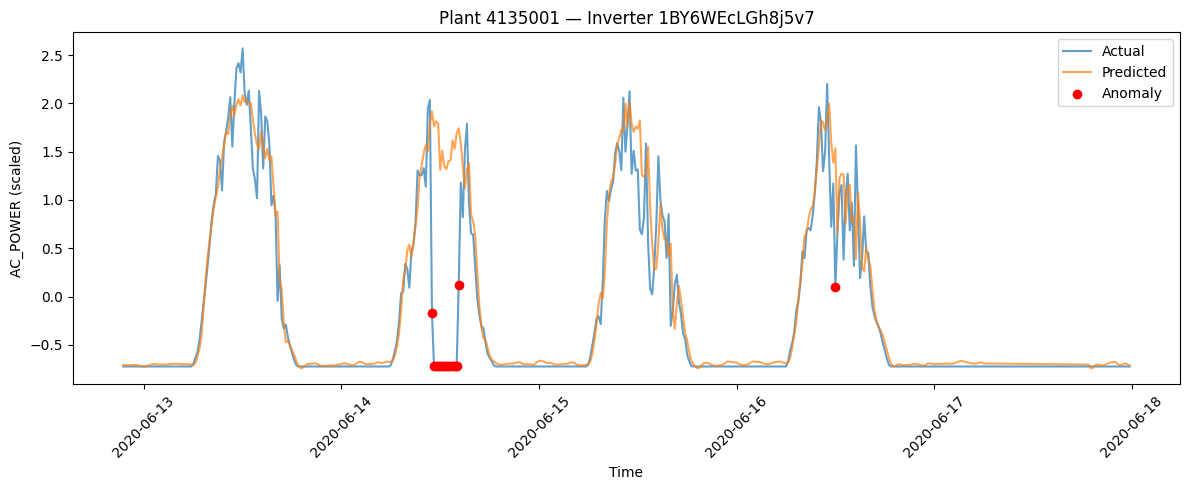

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Quick visualization for one inverte
sample_inverter = results['SOURCE_KEY'].iloc[0]
sample_plant = results['PLANT_ID'].iloc[0]
subset = results[(results.SOURCE_KEY == sample_inverter) & (results.PLANT_ID == sample_plant)].sort_values('DATE_TIME')

plt.figure(figsize=(12, 5))
plt.plot(subset['DATE_TIME'], subset['AC_POWER_actual_scaled'], label='Actual', alpha=0.7)
plt.plot(subset['DATE_TIME'], subset['AC_POWER_predicted_scaled'], label='Predicted', alpha=0.7)
anomaly_points = subset[subset['is_anomaly']]
plt.scatter(anomaly_points['DATE_TIME'], anomaly_points['AC_POWER_actual_scaled'], color='red', label='Anomaly', zorder=5)
plt.title(f'Plant {sample_plant} — Inverter {sample_inverter}')
plt.xlabel('Time'); plt.ylabel('AC_POWER (scaled)')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('sample_anomaly_plot.png', dpi=150)
plt.show()
files.download('sample_anomaly_plot.png')

In [21]:
# Write the Streamlit dashboard file (app.py)
dashboard_code = '''
import streamlit as st
import pandas as pd
import plotly.graph_objects as go

st.set_page_config(page_title="SUNSHIELD Anomaly Dashboard", layout="wide")
st.title("SUNSHIELD — PV Anomaly Detection Dashboard")

@st.cache_data
def load_data():
    df = pd.read_csv("anomaly_results_w48.csv")
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])
    return df

df = load_data()

st.sidebar.header("Filters")
plant = st.sidebar.selectbox("Plant", sorted(df["PLANT_ID"].unique()))
inverters = sorted(df[df["PLANT_ID"] == plant]["SOURCE_KEY"].unique())
inverter = st.sidebar.selectbox("Inverter", inverters)

subset = df[(df["PLANT_ID"] == plant) & (df["SOURCE_KEY"] == inverter)].sort_values("DATE_TIME")

col1, col2, col3 = st.columns(3)
col1.metric("Total readings", len(subset))
col2.metric("Anomalies detected", int(subset["is_anomaly"].sum()))
col3.metric("Anomaly rate", f"{100*subset['is_anomaly'].mean():.1f}%")

fig = go.Figure()
fig.add_trace(go.Scatter(x=subset["DATE_TIME"], y=subset["AC_POWER_actual_scaled"], mode="lines", name="Actual AC_POWER"))
fig.add_trace(go.Scatter(x=subset["DATE_TIME"], y=subset["AC_POWER_predicted_scaled"], mode="lines", name="Predicted AC_POWER"))
anomalies = subset[subset["is_anomaly"]]
fig.add_trace(go.Scatter(x=anomalies["DATE_TIME"], y=anomalies["AC_POWER_actual_scaled"], mode="markers", name="Anomaly", marker=dict(color="red", size=8)))
fig.update_layout(title=f"Plant {plant} — Inverter {inverter}", xaxis_title="Time", yaxis_title="AC_POWER (scaled)")
st.plotly_chart(fig, use_container_width=True)

st.subheader("Detected Anomalies")
st.dataframe(anomalies[["DATE_TIME", "AC_POWER_actual_scaled", "AC_POWER_predicted_scaled", "residual"]])
'''

with open('app.py', 'w') as f:
    f.write(dashboard_code)

files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>